# Reproducible Performance Analysis

This notebook provides data processing and result visualization for the performance evaluation of lightweight convolutional neural networks trained on the Tiny ImageNet dataset. Experimental metrics are extracted from structured logs produced during controlled execution on a cluster environment.

The analyses enable quantitative comparison among selected architectures in terms of accuracy evolution, loss behavior, and system-level resource indicators collected during training.


## Data Loading

A set of structured CSV files contains the full record of metrics collected during each training execution.  
These files encode:

- Epoch-wise training and validation statistics
- Telemetry sampled from the execution environment
- Execution identifiers (architecture and random seed)

This stage locates and enumerates all available logs, preparing them for parsing and merging into a single analytical dataset.


In [5]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(".").resolve()
LOGS_DIR = PROJECT_DIR / "logs_csv"

print("Found:", LOGS_DIR.exists())

csv_files = sorted(LOGS_DIR.glob("**/*.csv"))
len(csv_files), csv_files[:5]


Found: True


(20,
 [WindowsPath('C:/Users/Fernando Tedesco/Desktop/relatorio/CNNs-Performance-Analysis-main/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_201648.csv'),
  WindowsPath('C:/Users/Fernando Tedesco/Desktop/relatorio/CNNs-Performance-Analysis-main/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_205133.csv'),
  WindowsPath('C:/Users/Fernando Tedesco/Desktop/relatorio/CNNs-Performance-Analysis-main/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_211222.csv'),
  WindowsPath('C:/Users/Fernando Tedesco/Desktop/relatorio/CNNs-Performance-Analysis-main/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_213733.csv'),
  WindowsPath('C:/Users/Fernando Tedesco/Desktop/relatorio/CNNs-Performance-Analysis-main/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_221232.csv')])

## Merging Logs and Parsing Metadata

Each CSV file represents one execution with a specific CNN architecture and random seed.
Model name and seed identifier are encoded in the file path.  
These attributes are extracted and included as structured columns in the dataset.

The individual logs are then concatenated into a unified table to enable aggregated analysis
across architectures and repeated executions.


In [7]:
from pathlib import Path
import pandas as pd

LOGS_DIR = Path("logs_csv")
csv_files = sorted(LOGS_DIR.glob("*/*.csv"))

def load_single_log(path: Path) -> pd.DataFrame:
    # First row: metadata (model_name, seed, etc.)
    meta = pd.read_csv(path, nrows=1)
    model = meta["model_name"].iloc[0]
    seed = int(meta["seed"].iloc[0])

    # From third line onward: epoch-wise metrics
    metrics = pd.read_csv(path, skiprows=2)

    metrics["model"] = model
    metrics["seed"] = seed
    metrics["log_file"] = path.name
    return metrics

frames = [load_single_log(p) for p in csv_files]
logs_df = pd.concat(frames, ignore_index=True)

logs_df.head()



,epoch,train_loss,lr,elapsed_time_seconds,cpu_usage_percent,ram_peak_bytes,disk_read_bytes,disk_write_bytes,vram_peak_bytes,gpu_power_watts_avg,...,gpu_mem_used_bytes_avg,gpu_mem_used_bytes_peak,gpu_vram_used_bytes,val_accuracy,val_precision,val_recall,val_f1,model,seed,log_file
0,1,4.8095,0.1,6.4676,5.1312,8.524812e+09,0.0,16674816.0,2.760595e+09,108.1205,...,1.918796e+10,1.918796e+10,1.918796e+10,0.0929,0.0952,0.0929,0.0713,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
1,2,4.3001,0.1,6.1770,5.1688,8.528073e+09,0.0,2555904.0,2.760595e+09,127.9190,...,1.992616e+10,1.992616e+10,1.992616e+10,0.1688,0.1687,0.1688,0.1389,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
2,3,4.0624,0.1,6.0217,5.2188,8.798392e+09,0.0,6397952.0,2.760595e+09,128.3130,...,1.992616e+10,1.992616e+10,1.992616e+10,0.2148,0.2536,0.2148,0.1920,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
3,4,3.9119,0.1,6.2683,5.0875,8.813523e+09,0.0,4358144.0,2.760595e+09,124.2560,...,1.992616e+10,1.992616e+10,1.992616e+10,0.2322,0.2742,0.2322,0.2151,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
4,5,3.8015,0.1,6.2783,5.1063,8.828981e+09,0.0,10964992.0,2.760595e+09,127.6517,...,1.992616e+10,1.992616e+10,1.992616e+10,0.2661,0.3104,0.2661,0.2524,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...


## Validation Metrics Overview

For each architecture, five independent executions were performed using different random seeds.  
This enables statistical confidence when comparing performance across models.

The validation accuracy and F1-score logs are inspected to confirm:
- presence of all epochs recorded
- correct association of samples to model and execution seed
- no missing values in essential fields

The following summary provides an initial verification of metric consistency.


In [8]:
# Inspect distinct models and seed counts
models = logs_df['model'].unique()
seed_counts = logs_df.groupby('model')['seed'].nunique()

print("Detected models:", models)
print("\nSeed count per model:")
print(seed_counts)

# Check for missing metrics (sanity validation)
missing = logs_df[['val_accuracy', 'val_f1']].isna().sum()
missing


Detected models: ['efficientnet_b0' 'mobilenet_V1' 'shufflenet_v2' 'squeezenet']

Seed count per model:
model
efficientnet_b0    5
mobilenet_V1       5
shufflenet_v2      5
squeezenet         5
Name: seed, dtype: int64


val_accuracy    0
val_f1          0
dtype: int64

### Confidence Interval Aggregation

For each model and epoch, validation metrics from the five executions
(seeds) are aggregated. We compute:

- Mean validation accuracy
- 95% CI for validation accuracy
- Mean validation F1-score
- 95% CI for validation F1-score

These aggregated series will be used in the comparative plots that follow.


In [11]:
import numpy as np
# Compute mean and CI95 for accuracy + F1 per model & epoch
agg_df = (
    logs_df.groupby(['model', 'epoch'])
           .agg(
               val_acc_mean=('val_accuracy', 'mean'),
               val_acc_std=('val_accuracy', 'std'),
               val_f1_mean=('val_f1', 'mean'),
               val_f1_std=('val_f1', 'std'),
               n=('val_accuracy', 'count')
           )
           .reset_index()
)

# Confidence interval width = 1.96 * std / sqrt(n)
agg_df['val_acc_ci95'] = 1.96 * agg_df['val_acc_std'] / np.sqrt(agg_df['n'])
agg_df['val_f1_ci95'] = 1.96 * agg_df['val_f1_std'] / np.sqrt(agg_df['n'])

agg_df.head()


,model,epoch,val_acc_mean,val_acc_std,val_f1_mean,val_f1_std,n,val_acc_ci95,val_f1_ci95
0,efficientnet_b0,1,0.10176,0.005875,0.07548,0.002695,5,0.005150,0.002362
1,efficientnet_b0,2,0.16888,0.010582,0.14306,0.006919,5,0.009276,0.006065
2,efficientnet_b0,3,0.21866,0.008296,0.19554,0.007620,5,0.007272,0.006679
3,efficientnet_b0,4,0.24272,0.012006,0.22260,0.008637,5,0.010523,0.007571
4,efficientnet_b0,5,0.27182,0.008057,0.25246,0.007196,5,0.007062,0.006308


## Validation Curves with 95% Confidence Intervals

This section visualizes model performance throughout training.
For each epoch and architecture, the mean validation metric across
five independent runs is plotted as a solid line, while shaded
regions represent 95% confidence intervals. These bands indicate the
statistical reliability of the observed differences between models.


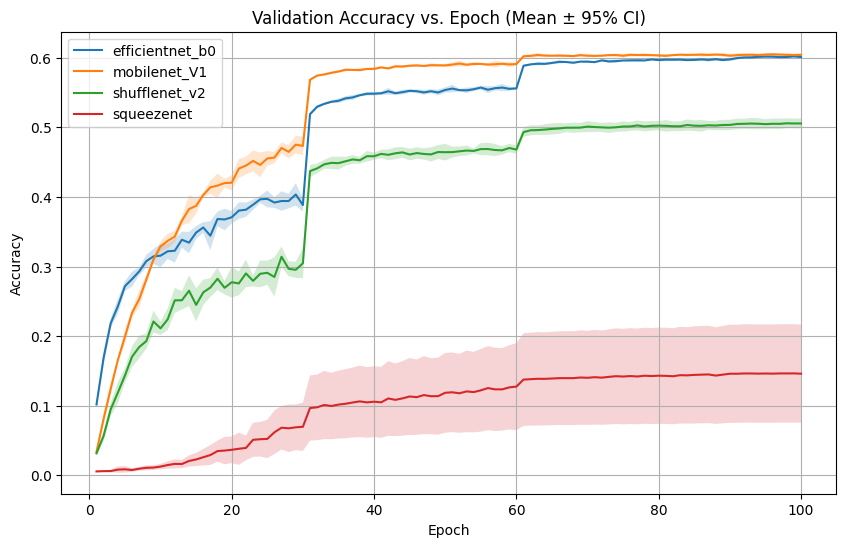

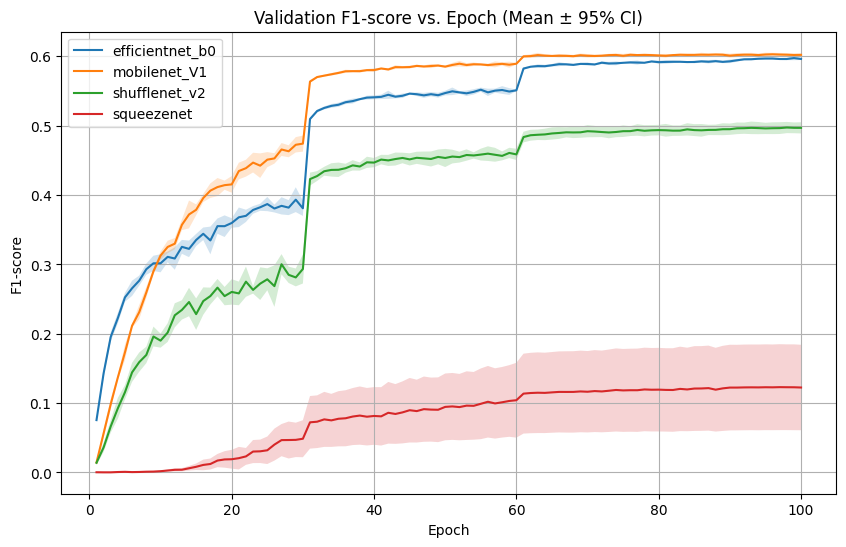

In [12]:
import matplotlib.pyplot as plt

# --- Plot Accuracy ---
plt.figure(figsize=(10, 6))
for model in agg_df['model'].unique():
    subset = agg_df[agg_df['model'] == model]
    plt.plot(subset['epoch'], subset['val_acc_mean'], label=model)
    plt.fill_between(
        subset['epoch'],
        subset['val_acc_mean'] - subset['val_acc_ci95'],
        subset['val_acc_mean'] + subset['val_acc_ci95'],
        alpha=0.2
    )

plt.title("Validation Accuracy vs. Epoch (Mean ± 95% CI)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot F1-score ---
plt.figure(figsize=(10, 6))
for model in agg_df['model'].unique():
    subset = agg_df[agg_df['model'] == model]
    plt.plot(subset['epoch'], subset['val_f1_mean'], label=model)
    plt.fill_between(
        subset['epoch'],
        subset['val_f1_mean'] - subset['val_f1_ci95'],
        subset['val_f1_mean'] + subset['val_f1_ci95'],
        alpha=0.2
    )

plt.title("Validation F1-score vs. Epoch (Mean ± 95% CI)")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()


## GPU Resource Metrics (Mean Across Runs)

Hardware-level metrics such as GPU utilization, memory usage and temperature
are inherently noisy even under identical configurations, due to effects such as
kernel scheduling, cooling control loops and driver-level activity. For these
signals, confidence intervals become visually dominant without adding much
interpretive value. 

To focus on deployment-relevant behavior, we report the **mean value across
the five executions** for each model and epoch, comparing the evolution of:
- average GPU utilization,
- average GPU memory usage (VRAM),
- average GPU temperature.



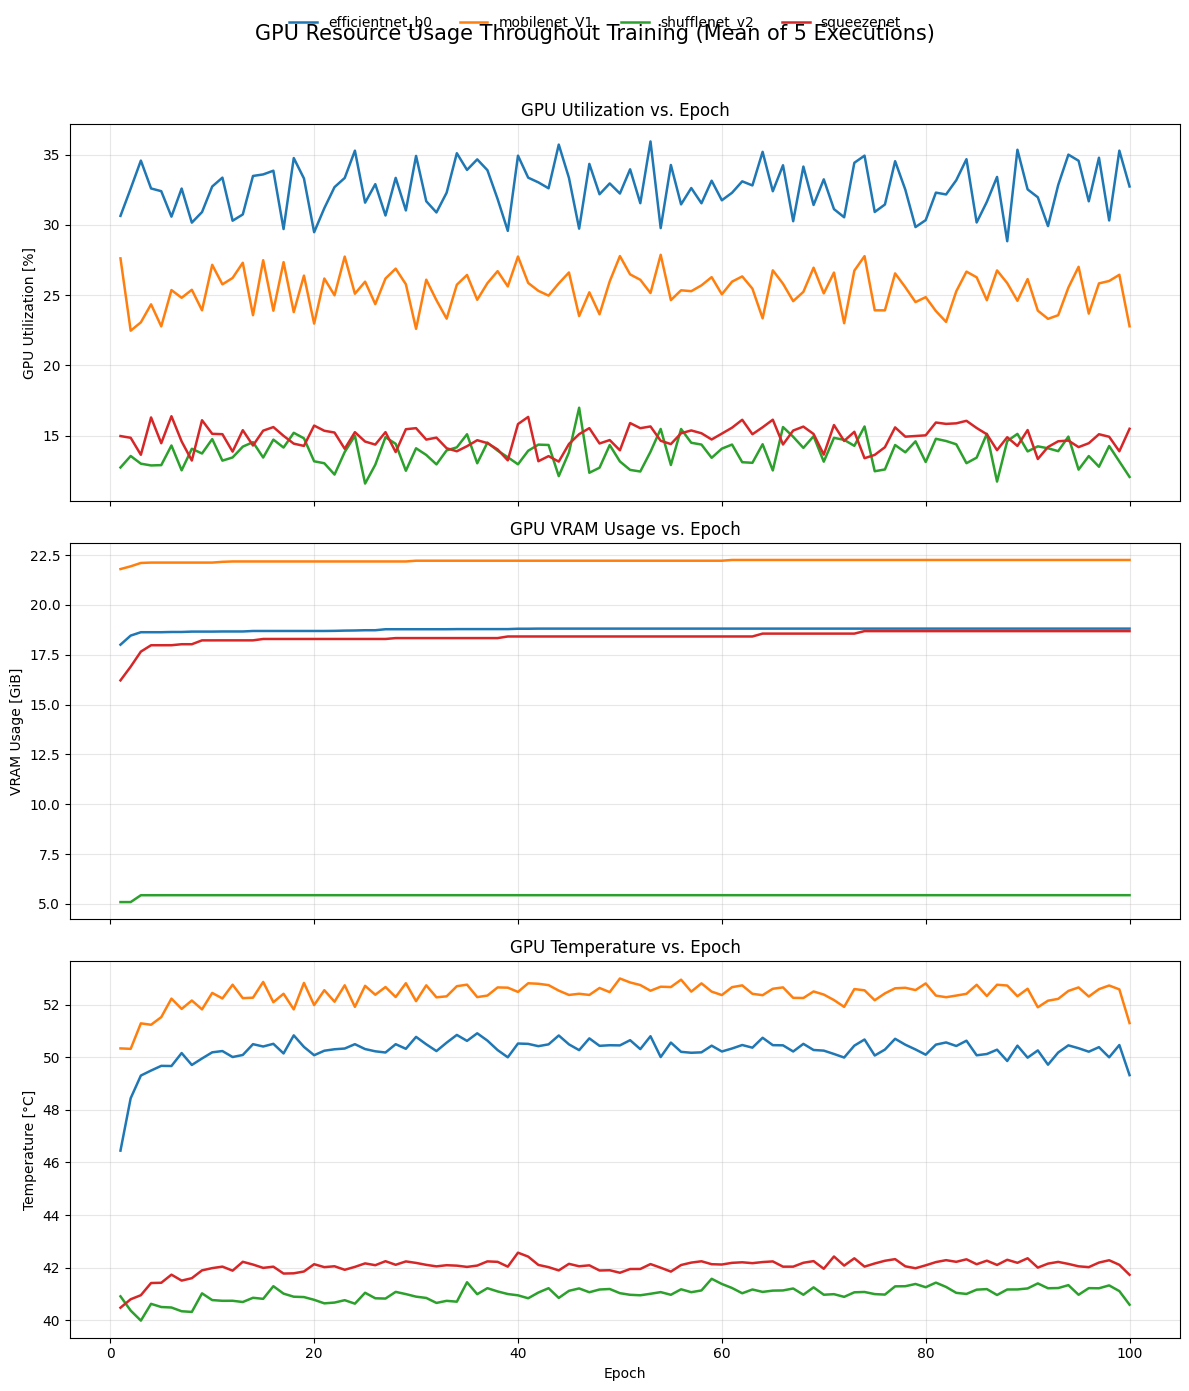

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Aggregate GPU-related metrics per model and epoch (mean over runs)
eff_df = (
    logs_df.groupby(["model", "epoch"])
    .agg(
        gpu_util_mean=("gpu_util_percent_avg", "mean"),
        gpu_vram_mean=("gpu_mem_used_bytes_avg", "mean"),
        gpu_temp_mean=("gpu_temp_celsius_avg", "mean"),
    )
    .reset_index()
)

gpu_models = eff_df["model"].unique()

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

metric_plots = [
    ("gpu_util_mean", "GPU Utilization [%]", "GPU Utilization vs. Epoch"),
    ("gpu_vram_mean", "VRAM Usage [GiB]", "GPU VRAM Usage vs. Epoch"),
    ("gpu_temp_mean", "Temperature [°C]", "GPU Temperature vs. Epoch"),
]

for ax, (metric, ylabel, title) in zip(axes, metric_plots):
    for model in gpu_models:
        subset = eff_df[eff_df["model"] == model]

        y = subset[metric]
        # Convert bytes → GiB only for VRAM
        if metric == "gpu_vram_mean":
            y = y / (1024 ** 3)

        ax.plot(subset["epoch"], y, label=model, linewidth=1.8)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Epoch")

fig.suptitle(
    "GPU Resource Usage Throughout Training (Mean of 5 Executions)",
    fontsize=15,
)
fig.legend(
    gpu_models,
    loc="upper center",
    ncol=len(gpu_models),
    frameon=False,
    bbox_to_anchor=(0.5, 0.995),
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

